# Fraud Detection on 590,540 E-Commerce Transactions
## When Intuition Fails: Velocity Traps and Relational Fraud Signals — Part 3 of a Series on Imbalanced Financial Data

## 1. Introduction

### About the Dataset

This notebook uses the **IEEE-CIS Fraud Detection** dataset, published by the IEEE Computational Intelligence Society in partnership with **Vesta Corporation** — a real-world e-commerce payment services provider. The data comes from actual card-not-present transactions collected over a six-month period.

The dataset is split across two files joined on TransactionID:
- **train_transaction.csv** — 590,540 rows, 394 features
- **train_identity.csv** — identity information for a subset of transactions (41 features)

*Dataset: IEEE-CIS Fraud Detection. [Kaggle](https://www.kaggle.com/competitions/ieee-fraud-detection). Data provided by Vesta Corporation.*

### What This Notebook Is Asking

Part 2 of this series established that domain-informed feature engineering — encoding accounting discrepancies that raw balance columns could not capture — produces a meaningful AUPRC lift on severely imbalanced fraud data. Three features that did not exist in the raw dataset accounted for over 70% of the model's discriminating power.

This notebook applies that same principle to a more complex dataset. The first step is building **behavioural fingerprinting** as the foundation layer: measuring how unusual each transaction is relative to that customer's own historical baseline. Not unusual compared to all customers — unusual compared to *this* customer.

Once the behavioural baseline is established, two hypotheses are tested on top of it:

**Hypothesis 1 — Velocity:** Fraud often follows a burst pattern. Transaction counts spike, spend escalates rapidly, new email domains appear in quick succession. Rolling time-window features that capture this acceleration should improve detection beyond the static behavioural baseline.

**Hypothesis 2 — Relational signal:** If velocity underperforms, the missing signal may not be temporal. It may be relational — one device reused across many cards, one address linked to many identities, one email domain appearing across suspicious clusters. Graph-inspired entity features can capture this without a full graph neural network.

Both hypotheses are tested and validated not just on a random split, but on a temporal split — training on the first half of the dataset and evaluating on the second. That is the test that matters in practice.

### Series Context

- **Part 1** (ZIMS): Signal hidden in text across 128M records — streaming NLP pipeline, Macro F1
- **Part 2** (PaySim): Signal hidden in accounting relationships — balance anomaly, drain ratio, AUPRC
- **Part 3** (IEEE-CIS): Behavioural fingerprinting as foundation, velocity and relational signals tested on top, temporal stability as the verdict

The thread connecting all three: the fraud signal is never where you first look for it.


## 2. Imports & Setup

In [1]:
import os
import gc
import time
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    average_precision_score, roc_auc_score, f1_score,
    precision_recall_curve, confusion_matrix, classification_report,
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TARGET       = "isFraud"
PALETTE = {
    "genuine":     "#90CAF9",
    "fraud":       "#EF5350",
    "raw":         "#90CAF9",
    "behavioural": "#EF5350",
    "velocity":    "#C62828",
    "relational":  "#6A1B9A",
}

sns.set_theme(style="whitegrid")
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", "{:.4f}".format)
print("✓ Environment ready")

✓ Environment ready


## 3. Loading & Merging the Data

The dataset ships as two files. A left join on TransactionID keeps all transactions, filling missing identity fields with NaN — which is structurally meaningful, not a data quality problem.

In [2]:
BASE_DIR = os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, "datasets")

TX_PATH = os.path.join(DATA_DIR, "train_transaction.csv")
ID_PATH = os.path.join(DATA_DIR, "train_identity.csv")

train_transaction = pd.read_csv(TX_PATH)
train_identity    = pd.read_csv(ID_PATH)

df = train_transaction.merge(train_identity, on="TransactionID", how="left")

print(f"Transaction file: {train_transaction.shape[0]:,} rows × {train_transaction.shape[1]} columns")
print(f"Identity file:    {train_identity.shape[0]:,} rows × {train_identity.shape[1]} columns")
print(f"\nMerged dataset:   {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage:     {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

del train_transaction, train_identity
gc.collect()
print("✓ Raw files freed from memory")

Transaction file: 590,540 rows × 394 columns
Identity file:    144,233 rows × 41 columns

Merged dataset:   590,540 rows × 434 columns
Memory usage:     2.64 GB
✓ Raw files freed from memory


### 3.1 Class Distribution

Total transactions: 590,540
Fraud cases:        20,663  (3.50%)
Genuine cases:      569,877
Imbalance ratio:    1 : 28

Naive accuracy (predict all genuine): 96.50%  ← meaningless
Random AUPRC baseline:                 0.0350


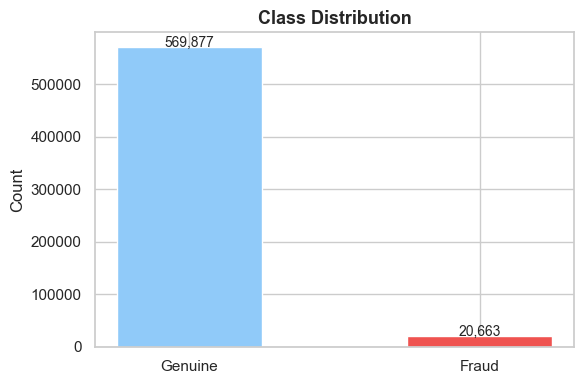

In [3]:
fraud_count   = int(df[TARGET].sum())
genuine_count = int((df[TARGET] == 0).sum())
fraud_rate    = df[TARGET].mean() * 100
imbalance     = genuine_count / fraud_count

print(f"Total transactions: {len(df):,}")
print(f"Fraud cases:        {fraud_count:,}  ({fraud_rate:.2f}%)")
print(f"Genuine cases:      {genuine_count:,}")
print(f"Imbalance ratio:    1 : {imbalance:.0f}")
print(f"\nNaive accuracy (predict all genuine): {100 - fraud_rate:.2f}%  ← meaningless")
print(f"Random AUPRC baseline:                 {fraud_rate/100:.4f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["Genuine", "Fraud"], [genuine_count, fraud_count],
       color=[PALETTE["genuine"], PALETTE["fraud"]], edgecolor="white", width=0.5)
ax.set_title("Class Distribution", fontsize=13, fontweight="bold")
ax.set_ylabel("Count")
for i, v in enumerate([genuine_count, fraud_count]):
    ax.text(i, v + 1000, f"{v:,}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

## 4. Where Part 2 Left Off

Part 2 of this series worked on the PaySim dataset — 6.3 million synthetic mobile money transactions with a 1:336 fraud-to-genuine imbalance. The central finding was that raw features were nearly useless for fraud detection on their own. Three engineered features built from accounting discrepancies in the balance columns accounted for over 70% of the model's discriminating power, achieving an AUPRC of 0.9981 against a random baseline of 0.003.

This notebook picks up from that principle — engineer signals that do not exist in the raw data — and applies it to a harder problem. Where PaySim had 7 features and needed new ones built from domain knowledge, IEEE-CIS has 400+ features and a different challenge: understanding which signals to trust and which to add.

The behavioural fingerprinting built in Section 6 is this notebook's equivalent of PaySim's accounting features — the engineered foundation that the rest of the analysis builds on. The table below shows Part 2 results for reference.


In [4]:
part2_raw_auprc    = 0.6727   # IEEE-CIS raw baseline (this notebook)
part2_paysim_auprc = 0.9981   # PaySim Part 2 final model AUPRC

recap = pd.DataFrame({
    "Stage":   ["PaySim — Raw baseline (Part 2)",
                "PaySim — Raw + engineered features (Part 2)",
                "IEEE-CIS — Raw baseline (this notebook)"],
    "AUPRC":   [None, part2_paysim_auprc, part2_raw_auprc],
    "Note":    ["PaySim had too few features — needed engineering from domain knowledge",
                "3 engineered features drove >70% of model discriminating power",
                "IEEE-CIS has 400+ features — different challenge entirely"],
})
print(recap.to_string(index=False))
print("\n→ Part 3 asks: which engineered signals add stable ranking power on IEEE-CIS?")


                                      Stage  AUPRC                                                                   Note
             PaySim — Raw baseline (Part 2)    NaN PaySim had too few features — needed engineering from domain knowledge
PaySim — Raw + engineered features (Part 2) 0.9981         3 engineered features drove >70% of model discriminating power
    IEEE-CIS — Raw baseline (this notebook) 0.6727              IEEE-CIS has 400+ features — different challenge entirely

→ Part 3 asks: which engineered signals add stable ranking power on IEEE-CIS?


## 5. Preprocessing

### 5.1 Time Features

`TransactionDT` is a timedelta in seconds from a reference date — not a real timestamp. We extract time-of-day features using cyclical sin/cos encoding before any engineering begins.

In [5]:
if "TransactionDT" not in df.columns:
    raise ValueError("TransactionDT is required for temporal validation.")

df["TransactionDay"] = (df["TransactionDT"] // (24 * 3600)).astype(int)
df["hour"]           = ((df["TransactionDT"] // 3600) % 24).astype(int)
df["hour_sin"]       = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"]       = np.cos(2 * np.pi * df["hour"] / 24)
print("✓ Time features created")

✓ Time features created


### 5.2 Drop High-Missing Columns

In [6]:
miss_rates        = df.isnull().mean()
high_missing_cols = miss_rates[miss_rates > 0.90].index.tolist()
df                = df.drop(columns=high_missing_cols)
print(f"Dropped {len(high_missing_cols)} columns with >90% missing values")
print(f"Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dropped 12 columns with >90% missing values
Dataset: 590,540 rows × 426 columns


### 5.3 Select Top V Features by Fraud Correlation

In [7]:
v_cols = [c for c in df.columns if c.startswith("V")]
v_corr = (
    df[v_cols + [TARGET]]
    .corr(numeric_only=True)[TARGET]
    .drop(TARGET).abs()
    .sort_values(ascending=False)
)
TOP_V       = 30
top_v_cols  = v_corr.head(TOP_V).index.tolist()
drop_v_cols = [c for c in v_cols if c not in top_v_cols]
df          = df.drop(columns=drop_v_cols)

print(f"Kept top {TOP_V} V features by absolute fraud correlation")
print(f"Dropped {len(drop_v_cols)} low-signal V features")
print(f"\nTop 10 V features:")
for feat, corr in v_corr.head(10).items():
    print(f"  {feat:<10}  {corr:.4f}")

Kept top 30 V features by absolute fraud correlation
Dropped 309 low-signal V features

Top 10 V features:
  V257        0.3831
  V246        0.3669
  V244        0.3641
  V242        0.3606
  V201        0.3280
  V200        0.3188
  V189        0.3082
  V188        0.3036
  V258        0.2972
  V45         0.2818


### 5.4 Build Customer UID — The Fingerprint Key

Using `card1` alone as a grouping key is too broad — it groups many different customers together, making the resulting baselines population averages in disguise. Combining multiple card and address columns produces a tighter per-customer identifier.

**Critical:** this must be computed before label encoding, on raw string values.

In [8]:
uid_parts = [c for c in ["card1", "card2", "card3", "card5", "addr1", "addr2"]
              if c in df.columns]
df["customer_uid"] = (
    df[uid_parts].astype(str).fillna("missing").agg("_".join, axis=1)
)
df["customer_uid_enc"] = df["customer_uid"].astype("category").cat.codes

n_unique = df["customer_uid"].nunique()
avg_txn  = len(df) / n_unique
print(f"Unique customer UIDs:         {n_unique:,}")
print(f"Average transactions per UID: {avg_txn:.1f}")
print(f"(vs {df['card1'].nunique():,} unique card1 values)")

Unique customer UIDs:         42,999
Average transactions per UID: 13.7
(vs 13,553 unique card1 values)


### 5.5 Email Consistency Features — Before Encoding

Email consistency features must be computed **before label encoding**. Encoding converts domain strings like `gmail.com` to integers; comparing integers for domain match produces meaningless results.

In [9]:
if "P_emaildomain" in df.columns and "R_emaildomain" in df.columns:
    df["email_domain_mismatch"] = (
        (df["P_emaildomain"].fillna("missing") != df["R_emaildomain"].fillna("missing"))
    ).astype(int)
else:
    df["email_domain_mismatch"] = 0

if "P_emaildomain" in df.columns:
    df["card_email_entropy"] = (
        df.groupby("customer_uid")["P_emaildomain"].transform("nunique").fillna(0)
    )
    modal_email = df.groupby("customer_uid")["P_emaildomain"].agg(
        lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
    )
    df["uid_modal_email"] = df["customer_uid"].map(modal_email)
    df["email_matches_history"] = (
        df["P_emaildomain"].fillna("missing") == df["uid_modal_email"].fillna("missing")
    ).astype(int)
else:
    df["card_email_entropy"]    = 0
    df["email_matches_history"] = 0

# Validate the email mismatch signal
mismatch_fraud_rate = df.loc[df.email_domain_mismatch==1, TARGET].mean() * 100
match_fraud_rate    = df.loc[df.email_domain_mismatch==0, TARGET].mean() * 100
print("✓ Email consistency features created (on raw strings)")
print(f"\nFraud rate — email mismatch: {mismatch_fraud_rate:.2f}%")
print(f"Fraud rate — email match:    {match_fraud_rate:.2f}%")

✓ Email consistency features created (on raw strings)

Fraud rate — email mismatch: 2.13%
Fraud rate — email match:    6.47%


The result is counterintuitive at first glance — transactions where the purchaser and recipient email domains match show a higher fraud rate (6.47%) than those where they mismatch (2.13%). The explanation is behavioural: unsophisticated fraud attempts often use mismatched domains and get caught by simpler rules before reaching this dataset. The fraud cases that survive into this dataset tend to be more deliberate — attackers who have studied the victim's account use the same email domain specifically to avoid triggering mismatch alerts. This is a pattern known as **low-and-slow fraud**: the attacker blends in by mimicking established account behaviour rather than standing out. The feature still carries signal, but not in the direction the naive hypothesis predicts. The model will learn the correct direction from the data; what matters is that the feature is present.

### 5.6 Encode Categorical Columns

In [10]:
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
for col in cat_cols:
    df[col] = df[col].fillna("missing").astype("category").cat.codes
print(f"✓ Encoded {len(cat_cols)} categorical columns")

✓ Encoded 31 categorical columns


## 6. Behavioural Fingerprinting

The principle from Part 2 was that the most important features were not in the raw data — they had to be engineered from domain knowledge. This section applies the same principle here, but the domain knowledge is different.

Instead of accounting discrepancies, the signal we are encoding is **behavioural deviation**: how unusual is this transaction relative to that customer's own history? Not unusual compared to all 590,000 transactions — unusual compared to *this customer's* established pattern.

We sort by customer and time first, then build four feature families: amount deviation, timing deviation, frequency deviation, and out-of-fold target encoding. These features do not exist in the raw dataset. They are constructed from it.


In [11]:
# Sort by customer and time before any deviation engineering
df = df.sort_values(["customer_uid_enc", "TransactionDT"]).reset_index(drop=True)
print("✓ Sorted by customer and time")

✓ Sorted by customer and time


### 6.1 Amount Deviation Features

In [12]:
print("Computing amount deviation features...")

cust_amt_mean  = df.groupby("customer_uid_enc")["TransactionAmt"].transform("mean")
cust_amt_std   = df.groupby("customer_uid_enc")["TransactionAmt"].transform("std").fillna(1)
cust_amt_max   = df.groupby("customer_uid_enc")["TransactionAmt"].transform("max")
cust_amt_count = df.groupby("customer_uid_enc")["TransactionAmt"].transform("count")

df["cust_amt_mean"]  = cust_amt_mean
df["cust_amt_std"]   = cust_amt_std
df["cust_amt_max"]   = cust_amt_max
df["cust_amt_count"] = cust_amt_count

df["amt_zscore"]        = np.where(cust_amt_std > 0,
                              (df["TransactionAmt"] - cust_amt_mean) / cust_amt_std, 0.0)
df["amt_to_mean_ratio"] = df["TransactionAmt"] / (cust_amt_mean + 1)
df["amt_to_max_ratio"]  = df["TransactionAmt"] / (cust_amt_max + 1)
df["is_new_cust_max"]   = (df["TransactionAmt"] >= cust_amt_max).astype(int)
df["card_age_norm"]     = 1 / (cust_amt_count + 1)

print("✓ Amount deviation features created")
sep = df.loc[df[TARGET]==1,"amt_zscore"].mean() - df.loc[df[TARGET]==0,"amt_zscore"].mean()
print(f"  amt_zscore separation (Fraud - Genuine): {sep:+.4f}")

Computing amount deviation features...
✓ Amount deviation features created
  amt_zscore separation (Fraud - Genuine): +0.1475


### 6.2 Timing Deviation Features

In [13]:
print("Computing timing deviation features...")

if "D1" in df.columns:
    d1_mean = df.groupby("customer_uid_enc")["D1"].transform("mean")
    d1_std  = df.groupby("customer_uid_enc")["D1"].transform("std").fillna(1)
    df["D1_cust_mean"] = d1_mean
    df["D1_cust_std"]  = d1_std
    df["D1_zscore"]    = np.where(d1_std > 0, (df["D1"] - d1_mean) / d1_std, 0.0)
else:
    df["D1_zscore"] = 0.0

prev_dt      = df.groupby("customer_uid_enc")["TransactionDT"].shift(1)
time_gap     = (df["TransactionDT"] - prev_dt).fillna(df["TransactionDT"].median())
df["cust_velocity"] = 1 / (time_gap + 1)

print("✓ Timing deviation features created")
sep = df.loc[df[TARGET]==1,"D1_zscore"].mean() - df.loc[df[TARGET]==0,"D1_zscore"].mean()
print(f"  D1_zscore separation (Fraud - Genuine): {sep:+.4f}")

Computing timing deviation features...
✓ Timing deviation features created
  D1_zscore separation (Fraud - Genuine): -0.1851


### 6.3 Frequency Deviation Features

In [14]:
print("Computing frequency deviation features...")

c_cols = [c for c in ["C1","C2","C4","C5","C6","C8","C9","C11","C13","C14"]
          if c in df.columns]

for c_col in c_cols:
    c_mean = df.groupby("customer_uid_enc")[c_col].transform("mean")
    c_std  = df.groupby("customer_uid_enc")[c_col].transform("std").fillna(1)
    df[f"{c_col}_deviation"] = np.where(c_std > 0, (df[c_col] - c_mean) / c_std, 0.0)

print("✓ Frequency deviation features created")
print("\nFraud - Genuine mean deviation:")
for col in [f"{c}_deviation" for c in c_cols]:
    diff = df.loc[df[TARGET]==1, col].mean() - df.loc[df[TARGET]==0, col].mean()
    flag = " ←" if abs(diff) > 0.1 else ""
    print(f"  {col:<20}  {diff:+.4f}{flag}")

Computing frequency deviation features...
✓ Frequency deviation features created

Fraud - Genuine mean deviation:
  C1_deviation          +0.1213 ←
  C2_deviation          +0.1457 ←
  C4_deviation          +0.2138 ←
  C5_deviation          -0.0909
  C6_deviation          +0.0838
  C8_deviation          +0.2024 ←
  C9_deviation          -0.0104
  C11_deviation         +0.1126 ←
  C13_deviation         -0.0572
  C14_deviation         -0.0503


### 6.4 Out-of-Fold Target Encoding

Target encoding replaces each category value with its mean fraud rate. Out-of-fold computation prevents target leakage — each row is encoded using statistics computed from the other folds only.

In [15]:
def target_encode_oof(data, col, target, n_splits=5, random_state=42):
    encoded     = pd.Series(np.nan, index=data.index)
    global_mean = data[target].mean()
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    for tr_idx, va_idx in skf.split(data, data[target]):
        mapping = data.iloc[tr_idx].groupby(col)[target].mean()
        encoded.iloc[va_idx] = data.iloc[va_idx][col].map(mapping).fillna(global_mean)
    return encoded.fillna(global_mean)

encode_cols = [c for c in ["customer_uid_enc","card1","card2","addr1",
                             "P_emaildomain","R_emaildomain"] if c in df.columns]

print("Computing out-of-fold target encodings...")
for col in encode_cols:
    df[f"{col}_te"] = target_encode_oof(df, col, TARGET)
    corr = df[f"{col}_te"].corr(df[TARGET])
    print(f"  ✓ {col}_te  (corr with isFraud: {corr:.4f})")

print("✓ Behavioural fingerprinting complete")

Computing out-of-fold target encodings...
  ✓ customer_uid_enc_te  (corr with isFraud: 0.4091)
  ✓ card1_te  (corr with isFraud: 0.3080)
  ✓ card2_te  (corr with isFraud: 0.2247)
  ✓ addr1_te  (corr with isFraud: 0.1004)
  ✓ P_emaildomain_te  (corr with isFraud: 0.0776)
  ✓ R_emaildomain_te  (corr with isFraud: 0.1823)
✓ Behavioural fingerprinting complete


## 7. Hypothesis 1 — Velocity Features

Velocity features are intuitive. Fraudsters burn through cards quickly — transaction counts spike, spend escalates rapidly, new email domains appear in quick succession. If we capture this burst behaviour through rolling time-window aggregations, the model should detect it.

That is the hypothesis. The question is not whether the story sounds plausible. The question is whether it **adds stable ranking power** on this dataset.

We compute three windows — 1 hour, 24 hours, and 7 days — using a vectorised numpy approach. Within each customer group, `np.searchsorted` finds the window boundary and numpy computes aggregates on the slice. No Python loops over customer UIDs.

In [16]:
print("Computing rolling velocity features (vectorised)...")
t0 = time.time()

vel = df[["customer_uid_enc", "TransactionDT", "TransactionAmt"]].copy()
if "P_emaildomain" in df.columns:
    vel["P_emaildomain"] = df["P_emaildomain"]
else:
    vel["P_emaildomain"] = -1

vel = vel.sort_values(["customer_uid_enc", "TransactionDT"]).reset_index()
vel.rename(columns={"index": "orig_idx"}, inplace=True)

WINDOWS = {"1h": 3600, "24h": 86400, "7d": 604800}
n_rows  = len(vel)

results = {}
for win_name in WINDOWS:
    results[f"txn_amt_sum_{win_name}"]  = np.zeros(n_rows, dtype=float)
    results[f"txn_count_{win_name}"]    = np.zeros(n_rows, dtype=float)
    results[f"txn_amt_max_{win_name}"]  = np.zeros(n_rows, dtype=float)
results["unique_emails_24h"] = np.zeros(n_rows, dtype=float)

pos = 0
for uid, grp in vel.groupby("customer_uid_enc", sort=True):
    n      = len(grp)
    times  = grp["TransactionDT"].to_numpy()
    amts   = grp["TransactionAmt"].to_numpy()
    emails = grp["P_emaildomain"].to_numpy()
    idx    = np.arange(pos, pos + n)
    pos   += n

    for win_name, win_sec in WINDOWS.items():
        left   = np.searchsorted(times, times - win_sec, side="left")
        cumsum = np.cumsum(amts)
        for i in range(n):
            l = left[i]
            results[f"txn_count_{win_name}"][idx[i]]   = i - l + 1
            results[f"txn_amt_sum_{win_name}"][idx[i]] = cumsum[i] - (cumsum[l-1] if l > 0 else 0.0)
            results[f"txn_amt_max_{win_name}"][idx[i]] = amts[l:i+1].max()

    left_24h = np.searchsorted(times, times - 86400, side="left")
    for i in range(n):
        results["unique_emails_24h"][idx[i]] = len(set(emails[left_24h[i]:i+1]))

for col, arr in results.items():
    vel[col] = arr

vel = vel.sort_values("orig_idx").set_index("orig_idx")
for col in results:
    df[col] = vel[col].values

vel_features = list(results.keys())
elapsed = time.time() - t0
print(f"✓ Velocity base features created in {elapsed:.1f}s")

Computing rolling velocity features (vectorised)...
✓ Velocity base features created in 13.8s


In [17]:
print("Computing acceleration features...")

df["txn_amt_sum_7d_daily"]  = df["txn_amt_sum_7d"] / 7.0
df["txn_count_7d_daily"]    = df["txn_count_7d"] / 7.0
df["amt_acceleration"]      = df["txn_amt_sum_24h"] / (df["txn_amt_sum_7d_daily"] + 1)
df["freq_acceleration"]     = df["txn_count_24h"]   / (df["txn_count_7d_daily"]   + 1)
df["email_burst_flag"]      = (df["unique_emails_24h"] > 1).astype(int)

acc_feats = ["amt_acceleration", "freq_acceleration", "email_burst_flag"]
print("✓ Velocity acceleration features created")

Computing acceleration features...
✓ Velocity acceleration features created


### 7.1 Diagnosing the Velocity Signal Before Modelling

Before fitting any model, the distributions should confirm whether velocity features actually separate fraud from genuine transactions. If the distributions overlap heavily, the feature may be more intuitive than useful.

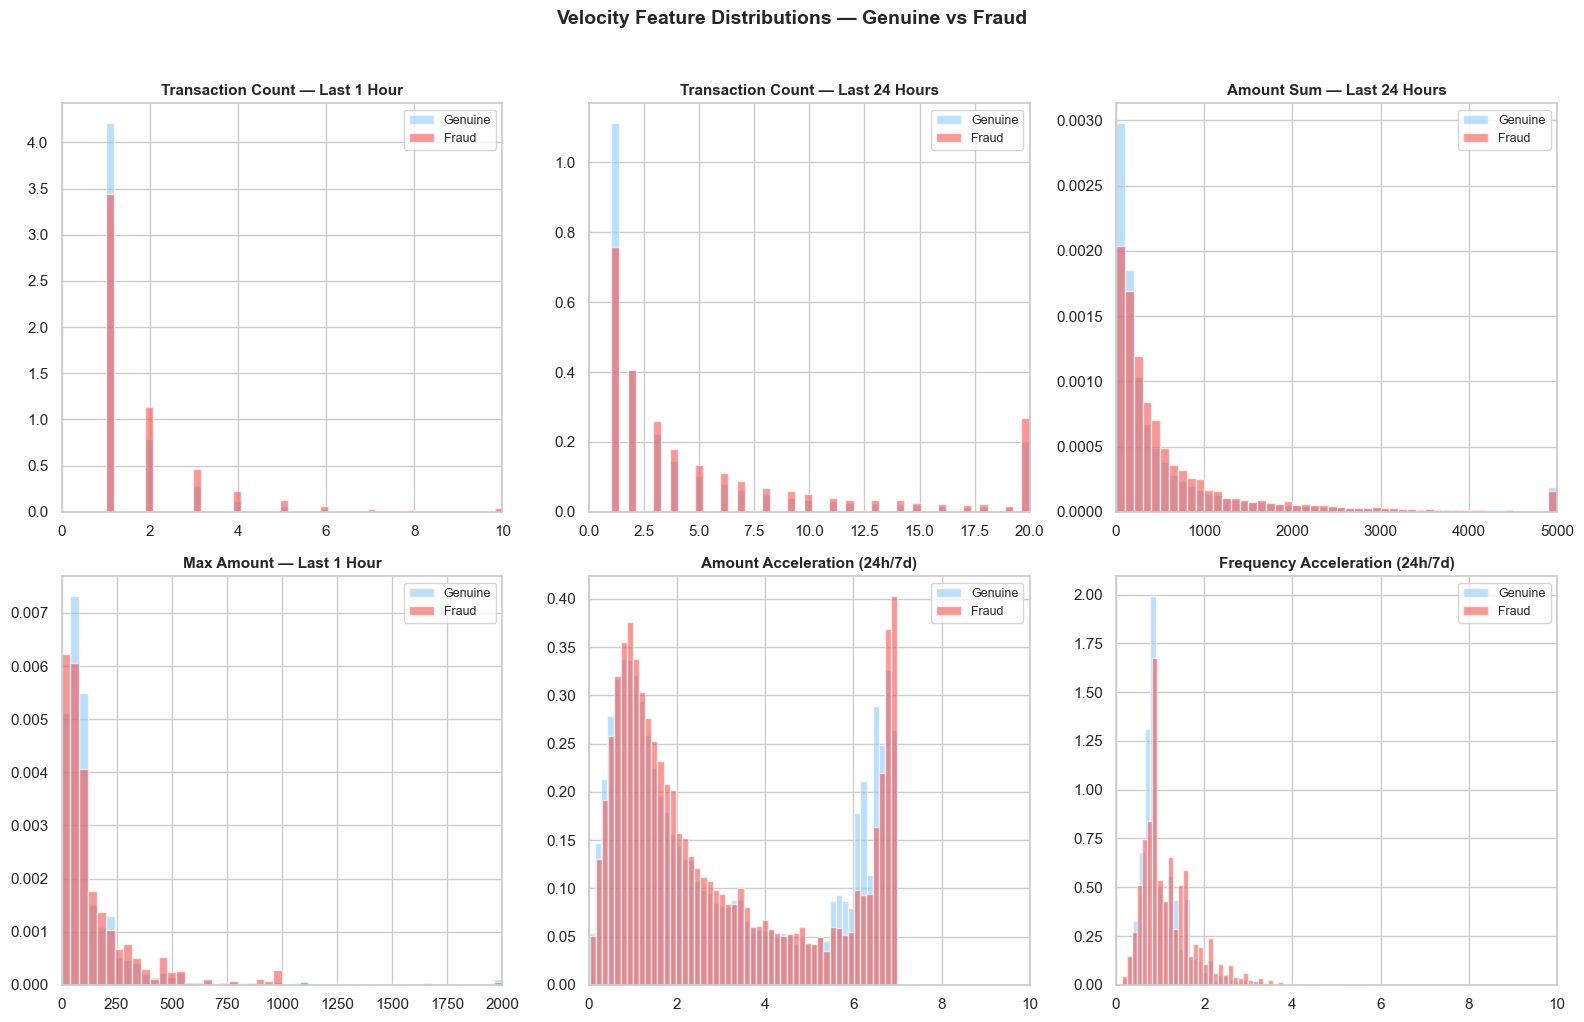

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

features_to_plot = [
    ("txn_count_1h",    "Transaction Count — Last 1 Hour",   (0, 10)),
    ("txn_count_24h",   "Transaction Count — Last 24 Hours", (0, 20)),
    ("txn_amt_sum_24h", "Amount Sum — Last 24 Hours",        (0, 5000)),
    ("txn_amt_max_1h",  "Max Amount — Last 1 Hour",          (0, 2000)),
    ("amt_acceleration","Amount Acceleration (24h/7d)",      (0, 10)),
    ("freq_acceleration","Frequency Acceleration (24h/7d)",  (0, 10)),
]

for i, (feat, title, xlim) in enumerate(features_to_plot):
    for label, name, col in [(0, "Genuine", PALETTE["genuine"]),
                              (1, "Fraud",   PALETTE["fraud"])]:
        vals = df.loc[df[TARGET] == label, feat].clip(*xlim)
        axes[i].hist(vals, bins=50, alpha=0.6, density=True,
                     color=col, label=name)
    axes[i].set_title(title, fontsize=11, fontweight="bold")
    axes[i].set_xlim(xlim)
    axes[i].legend(fontsize=9)

plt.suptitle("Velocity Feature Distributions — Genuine vs Fraud",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [19]:
# Statistical separation table
velocity_summary = []
for feat in vel_features + acc_feats:
    g = df.loc[df[TARGET]==0, feat].mean()
    f = df.loc[df[TARGET]==1, feat].mean()
    velocity_summary.append({
        "Feature": feat, "Genuine Mean": g, "Fraud Mean": f, "Difference": f - g
    })

vel_df = pd.DataFrame(velocity_summary).sort_values("Difference", key=np.abs, ascending=False)
print(f"{'Feature':<25} {'Genuine Mean':>14} {'Fraud Mean':>12} {'Diff':>10}")
print("-" * 65)
for _, row in vel_df.iterrows():
    flag = " ←" if abs(row["Difference"]) > 0.5 else ""
    print(f"{row['Feature']:<25} {row['Genuine Mean']:>14.3f} "
          f"{row['Fraud Mean']:>12.3f} {row['Difference']:>+10.3f}{flag}")

Feature                     Genuine Mean   Fraud Mean       Diff
-----------------------------------------------------------------
txn_amt_sum_7d                  3349.851     3185.704   -164.147 ←
txn_amt_max_7d                   435.439      385.618    -49.821 ←
txn_amt_sum_24h                  728.210      698.183    -30.027 ←
txn_amt_sum_1h                   209.093      232.957    +23.865 ←
txn_amt_max_1h                   147.179      161.000    +13.821 ←
txn_count_7d                      33.917       41.655     +7.738 ←
txn_count_24h                      6.853        7.925     +1.072 ←
txn_amt_max_24h                  230.179      229.490     -0.689 ←
txn_count_1h                       1.637        1.812     +0.175
amt_acceleration                   3.107        2.962     -0.145
freq_acceleration                  1.060        1.186     +0.126
unique_emails_24h                  2.215        2.287     +0.071
email_burst_flag                   0.460        0.521     +0.060


## 8. Hypothesis 2 — Relational Signal

If velocity underperforms, that does not mean there is no additional signal left. It may simply mean the missing signal is **not temporal**.

A more realistic fraud hypothesis is often relational:
- one device is reused across many cards
- one address is linked to many identities
- one email domain appears across suspicious clusters
- one card interacts with multiple unusual counterparties

We can capture part of this network effect without building a full graph neural network. The practical approach is to create **graph-inspired tabular features** from shared entities — counts and uniqueness measures that tell the model how many other entities a given card, address, or device touches.

### 8.1 Entity Count and Uniqueness Features

In [20]:
print("Computing relational features...")

relational_features = []

def add_count(data, group_col, name):
    data[name] = data.groupby(group_col)["TransactionID"].transform("count")
    relational_features.append(name)

def add_nunique(data, group_col, value_col, name):
    data[name] = data.groupby(group_col)[value_col].transform("nunique")
    relational_features.append(name)

if "card1"        in df.columns: add_count(df, "card1",        "card1_txn_count")
if "addr1"        in df.columns: add_count(df, "addr1",        "addr1_txn_count")
if "DeviceInfo"   in df.columns: add_count(df, "DeviceInfo",   "device_txn_count")
if "P_emaildomain"in df.columns: add_count(df, "P_emaildomain","p_email_txn_count")
if "R_emaildomain"in df.columns: add_count(df, "R_emaildomain","r_email_txn_count")

if "card1" in df.columns and "P_emaildomain" in df.columns:
    add_nunique(df, "card1",        "P_emaildomain", "card1_unique_p_email")
    add_nunique(df, "P_emaildomain","card1",          "p_email_unique_cards")

if "addr1"      in df.columns and "card1" in df.columns:
    add_nunique(df, "addr1",      "card1", "addr1_unique_cards")

if "DeviceInfo" in df.columns and "card1" in df.columns:
    add_nunique(df, "DeviceInfo", "card1",         "device_unique_cards")
    add_nunique(df, "DeviceInfo", "P_emaildomain", "device_unique_p_email")

print("✓ Relational count/uniqueness features created")
print(f"  {relational_features}")

Computing relational features...
✓ Relational count/uniqueness features created
  ['card1_txn_count', 'addr1_txn_count', 'device_txn_count', 'p_email_txn_count', 'r_email_txn_count', 'card1_unique_p_email', 'p_email_unique_cards', 'addr1_unique_cards', 'device_unique_cards', 'device_unique_p_email']


### 8.2 Leakage-Safe Relational Risk Encoding

Count features are useful, but relational modelling becomes much stronger when we estimate **entity risk** — the historical fraud rate associated with each card, email domain, or device.

These must be computed without leakage. We use out-of-fold target encoding for this purpose: for each fold, the validation set is encoded using statistics computed from the training fold only.

In [21]:
risk_cols = [c for c in ["card1","addr1","DeviceInfo","P_emaildomain","R_emaildomain"]
              if c in df.columns]
relational_risk_features = []

print("Computing relational risk encodings...")
for col in risk_cols:
    new_col = f"{col}_risk_te"
    df[new_col] = target_encode_oof(df, col, TARGET)
    corr = df[new_col].corr(df[TARGET])
    relational_risk_features.append(new_col)
    print(f"  ✓ {new_col}  (corr with isFraud: {corr:.4f})")

relational_features += relational_risk_features
print("✓ Relational risk features created")

Computing relational risk encodings...
  ✓ card1_risk_te  (corr with isFraud: 0.3080)
  ✓ addr1_risk_te  (corr with isFraud: 0.1004)
  ✓ DeviceInfo_risk_te  (corr with isFraud: 0.2585)
  ✓ P_emaildomain_risk_te  (corr with isFraud: 0.0776)
  ✓ R_emaildomain_risk_te  (corr with isFraud: 0.1823)
✓ Relational risk features created


## 9. Building the Final Feature Matrix

At this point we have four distinct feature families. The rest of the notebook compares them as fairly as possible — same learner, same hyperparameters, same evaluation metric.

| Family | Count | Description |
|---|---|---|
| Raw | ~111 | Original cleaned variables (top V, card, address, identity) |
| Behavioural | ~28 | Per-customer deviation features |
| Velocity | ~13 | Rolling time-window aggregations and acceleration |
| Relational | ~15 | Shared-entity counts and entity risk encodings |

In [22]:
BEHAVIOURAL_FEATURES = (
    ["amt_zscore","amt_to_mean_ratio","amt_to_max_ratio","is_new_cust_max",
     "card_age_norm","D1_zscore","cust_velocity","hour_sin","hour_cos",
     "email_matches_history","card_email_entropy","email_domain_mismatch"] +
    [f"{c}_deviation" for c in c_cols if f"{c}_deviation" in df.columns] +
    [f"{c}_te" for c in encode_cols if f"{c}_te" in df.columns]
)
BEHAVIOURAL_FEATURES = [f for f in BEHAVIOURAL_FEATURES if f in df.columns]
VELOCITY_FEATURES    = [f for f in vel_features + acc_feats if f in df.columns]
RELATIONAL_FEATURES  = [f for f in relational_features if f in df.columns]

drop_cols = [
    TARGET, "TransactionID", "TransactionDT", "TransactionDay", "hour",
    "customer_uid", "uid_modal_email",
    "cust_amt_mean","cust_amt_std","cust_amt_max","cust_amt_count",
    "D1_cust_mean","D1_cust_std",
    "txn_amt_sum_7d_daily","txn_count_7d_daily",
]
drop_cols = [c for c in drop_cols if c in df.columns]

y = df[TARGET].copy()
X = df.drop(columns=drop_cols).fillna(-999)

all_engineered = set(BEHAVIOURAL_FEATURES) | set(VELOCITY_FEATURES) | set(RELATIONAL_FEATURES)
raw_cols       = [c for c in X.columns if c not in all_engineered]

print(f"Total features:      {X.shape[1]}")
print(f"Raw features:        {len(raw_cols)}")
print(f"Behavioural:         {len(BEHAVIOURAL_FEATURES)}")
print(f"Velocity:            {len(VELOCITY_FEATURES)}")
print(f"Relational:          {len(RELATIONAL_FEATURES)}")

Total features:      167
Raw features:        111
Behavioural:         28
Velocity:            13
Relational:          15


## 10. Train / Test Split

We use two evaluation regimes:
- **Stratified random split** — the standard approach; answers whether the model ranks fraud well under typical validation conditions
- **Temporal split** — training on the first half of the dataset, evaluating on the second — the test that matters in practice

The random split answers: *can the model rank fraud well under typical validation?*
The temporal split answers: *does that ranking power survive a more realistic deployment-like setting?*

A feature family that improves AUPRC on the random split but collapses on the temporal split is not a reliable production signal. Both tests are needed to draw an honest conclusion.


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

X_train_raw  = X_train[raw_cols]
X_test_raw   = X_test[raw_cols]
X_train_beh  = X_train[raw_cols + BEHAVIOURAL_FEATURES]
X_test_beh   = X_test[raw_cols + BEHAVIOURAL_FEATURES]
X_train_vel  = X_train[raw_cols + BEHAVIOURAL_FEATURES + VELOCITY_FEATURES]
X_test_vel   = X_test[raw_cols + BEHAVIOURAL_FEATURES + VELOCITY_FEATURES]
X_train_rel  = X_train[raw_cols + BEHAVIOURAL_FEATURES + RELATIONAL_FEATURES]
X_test_rel   = X_test[raw_cols + BEHAVIOURAL_FEATURES + RELATIONAL_FEATURES]
X_train_full = X_train[raw_cols + BEHAVIOURAL_FEATURES + VELOCITY_FEATURES + RELATIONAL_FEATURES]
X_test_full  = X_test[raw_cols + BEHAVIOURAL_FEATURES + VELOCITY_FEATURES + RELATIONAL_FEATURES]

class_weight_ratio = (y_train == 0).sum() / float((y_train == 1).sum())
print(f"Class weight ratio: 1 : {class_weight_ratio:.0f}")
print(f"Training set: {X_train.shape[0]:,} rows")
print(f"Test set:     {X_test.shape[0]:,} rows  ({y_test.mean()*100:.2f}% fraud)")

Class weight ratio: 1 : 28
Training set: 472,432 rows
Test set:     118,108 rows  (3.50% fraud)


## 11. Modelling — Five-Way Feature Family Comparison

We keep the same XGBoost learner and hyperparameters across all five models. The comparison isolates the contribution of each feature family — not the model type.

| Model | Features | Question Answered |
|---|---|---|
| Raw | 111 | What does the cleaned raw baseline achieve? |
| + Behavioural | 139 | Does per-customer fingerprinting help? |
| + Velocity | 152 | Does burst behaviour detection add further value? |
| + Relational | 154 | Does entity-level shared signal help? |
| Full | 167 | Does combining all families outperform any single layer? |

In [24]:
def train_and_evaluate(X_tr, X_te, y_tr, y_te, label, class_w):
    clf = XGBClassifier(
        n_estimators=600, max_depth=7, learning_rate=0.03,
        scale_pos_weight=class_w, subsample=0.8,
        colsample_bytree=0.6, colsample_bylevel=0.6,
        min_child_weight=30, reg_alpha=0.1, reg_lambda=1.0,
        eval_metric="aucpr", early_stopping_rounds=40,
        n_jobs=4, random_state=RANDOM_STATE, verbosity=0,
    )
    t0 = time.time()
    clf.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=False)
    elapsed = time.time() - t0

    probas = clf.predict_proba(X_te)[:, 1]
    preds  = clf.predict(X_te)
    res = {
        "label":    label,
        "features": X_tr.shape[1],
        "auprc":    average_precision_score(y_te, probas),
        "auroc":    roc_auc_score(y_te, probas),
        "f1":       f1_score(y_te, preds),
        "time_s":   elapsed,
        "probas":   probas,
        "preds":    preds,
        "model":    clf,
        "columns":  list(X_tr.columns),
    }
    print(f"[{label:<38}] Feats: {X_tr.shape[1]:>4} | "
          f"AUPRC: {res['auprc']:.4f} | AUROC: {res['auroc']:.4f} | "
          f"F1: {res['f1']:.4f} | Time: {elapsed:.1f}s")
    return res

print("Training models...")
print("-" * 100)
res_raw  = train_and_evaluate(X_train_raw,  X_test_raw,  y_train, y_test, "Raw features",                      class_weight_ratio)
res_beh  = train_and_evaluate(X_train_beh,  X_test_beh,  y_train, y_test, "Raw + behavioural",                 class_weight_ratio)
res_vel  = train_and_evaluate(X_train_vel,  X_test_vel,  y_train, y_test, "Raw + behavioural + velocity",       class_weight_ratio)
res_rel  = train_and_evaluate(X_train_rel,  X_test_rel,  y_train, y_test, "Raw + behavioural + relational",     class_weight_ratio)
res_full = train_and_evaluate(X_train_full, X_test_full, y_train, y_test, "Full (all families)",                class_weight_ratio)

Training models...
----------------------------------------------------------------------------------------------------
[Raw features                          ] Feats:  111 | AUPRC: 0.6917 | AUROC: 0.9486 | F1: 0.4113 | Time: 699.5s
[Raw + behavioural                     ] Feats:  139 | AUPRC: 0.7754 | AUROC: 0.9675 | F1: 0.4858 | Time: 175.6s
[Raw + behavioural + velocity          ] Feats:  152 | AUPRC: 0.7738 | AUROC: 0.9672 | F1: 0.4888 | Time: 562.3s
[Raw + behavioural + relational        ] Feats:  154 | AUPRC: 0.7829 | AUROC: 0.9688 | F1: 0.4946 | Time: 248.4s
[Full (all families)                   ] Feats:  167 | AUPRC: 0.7792 | AUROC: 0.9681 | F1: 0.4923 | Time: 241.4s


### 11.1 Random-Split Comparison

In [25]:
comparison = pd.DataFrame([
    {"Model": r["label"], "Features": r["features"],
     "AUPRC": round(r["auprc"],4), "AUROC": round(r["auroc"],4),
     "F1": round(r["f1"],4), "Train Time (s)": round(r["time_s"],1)}
    for r in [res_raw, res_beh, res_vel, res_rel, res_full]
]).sort_values("AUPRC", ascending=False)

print("\n" + "="*75)
print("RANDOM-SPLIT MODEL COMPARISON")
print("="*75)
print(comparison.to_string(index=False))
print("="*75)

def pp(new, old): return (new - old) * 100

print(f"\nBehavioural lift over raw:          {pp(res_beh['auprc'], res_raw['auprc']):+.2f} pp")
print(f"Velocity lift over behavioural:     {pp(res_vel['auprc'], res_beh['auprc']):+.2f} pp")
print(f"Relational lift over behavioural:   {pp(res_rel['auprc'], res_beh['auprc']):+.2f} pp")
print(f"Full lift over behavioural:         {pp(res_full['auprc'], res_beh['auprc']):+.2f} pp")


RANDOM-SPLIT MODEL COMPARISON
                         Model  Features  AUPRC  AUROC     F1  Train Time (s)
Raw + behavioural + relational       154 0.7829 0.9688 0.4946        248.4000
           Full (all families)       167 0.7792 0.9681 0.4923        241.4000
             Raw + behavioural       139 0.7754 0.9675 0.4858        175.6000
  Raw + behavioural + velocity       152 0.7738 0.9672 0.4888        562.3000
                  Raw features       111 0.6917 0.9486 0.4113        699.5000

Behavioural lift over raw:          +8.37 pp
Velocity lift over behavioural:     -0.16 pp
Relational lift over behavioural:   +0.75 pp
Full lift over behavioural:         +0.38 pp


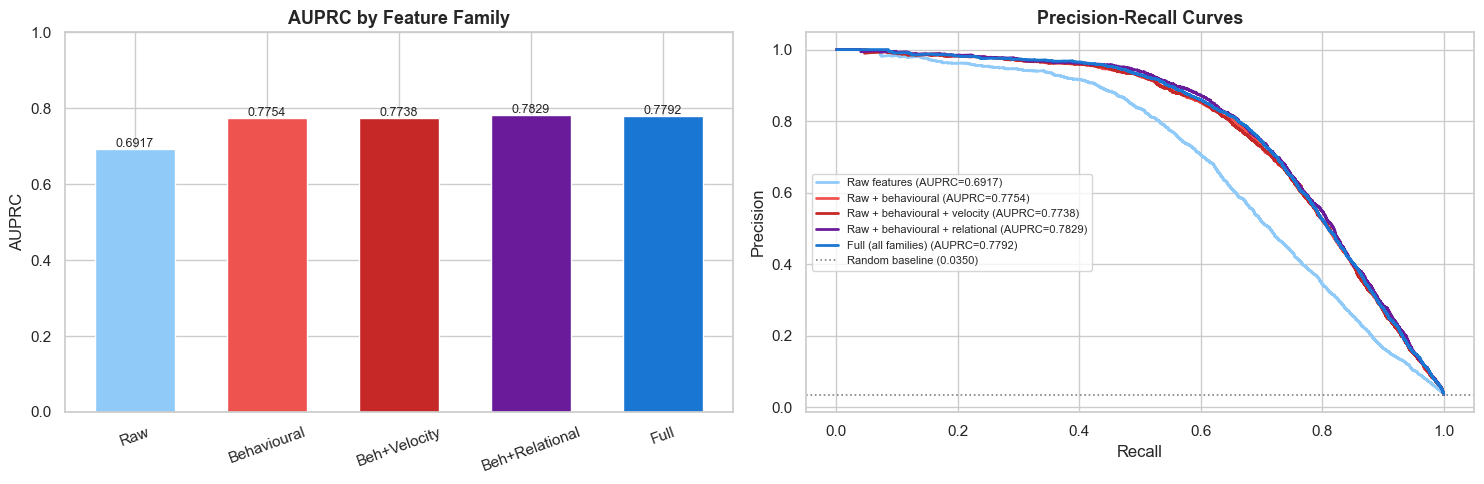

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ordered = [res_raw, res_beh, res_vel, res_rel, res_full]
labels  = ["Raw", "Behavioural", "Beh+Velocity", "Beh+Relational", "Full"]
auprcs  = [r["auprc"] for r in ordered]
bar_colors = [PALETTE["raw"], PALETTE["behavioural"], PALETTE["velocity"],
              PALETTE["relational"], "#1976D2"]

bars = axes[0].bar(labels, auprcs, color=bar_colors, edgecolor="white", width=0.6)
axes[0].set_title("AUPRC by Feature Family", fontsize=13, fontweight="bold")
axes[0].set_ylabel("AUPRC")
axes[0].tick_params(axis="x", rotation=20)
axes[0].set_ylim(0, 1)
for bar, v in zip(bars, auprcs):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.005,
                 f"{v:.4f}", ha="center", fontsize=9)

baseline_auprc = y_test.mean()
for res, col in zip(ordered, bar_colors):
    p, r, _ = precision_recall_curve(y_test, res["probas"])
    axes[1].plot(r, p, lw=2, color=col,
                 label=f"{res['label']} (AUPRC={res['auprc']:.4f})")

axes[1].axhline(y=baseline_auprc, linestyle=":", lw=1.2, color="grey",
                label=f"Random baseline ({baseline_auprc:.4f})")
axes[1].set_title("Precision-Recall Curves", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### 11.2 Feature Importance — What Actually Drove the Model

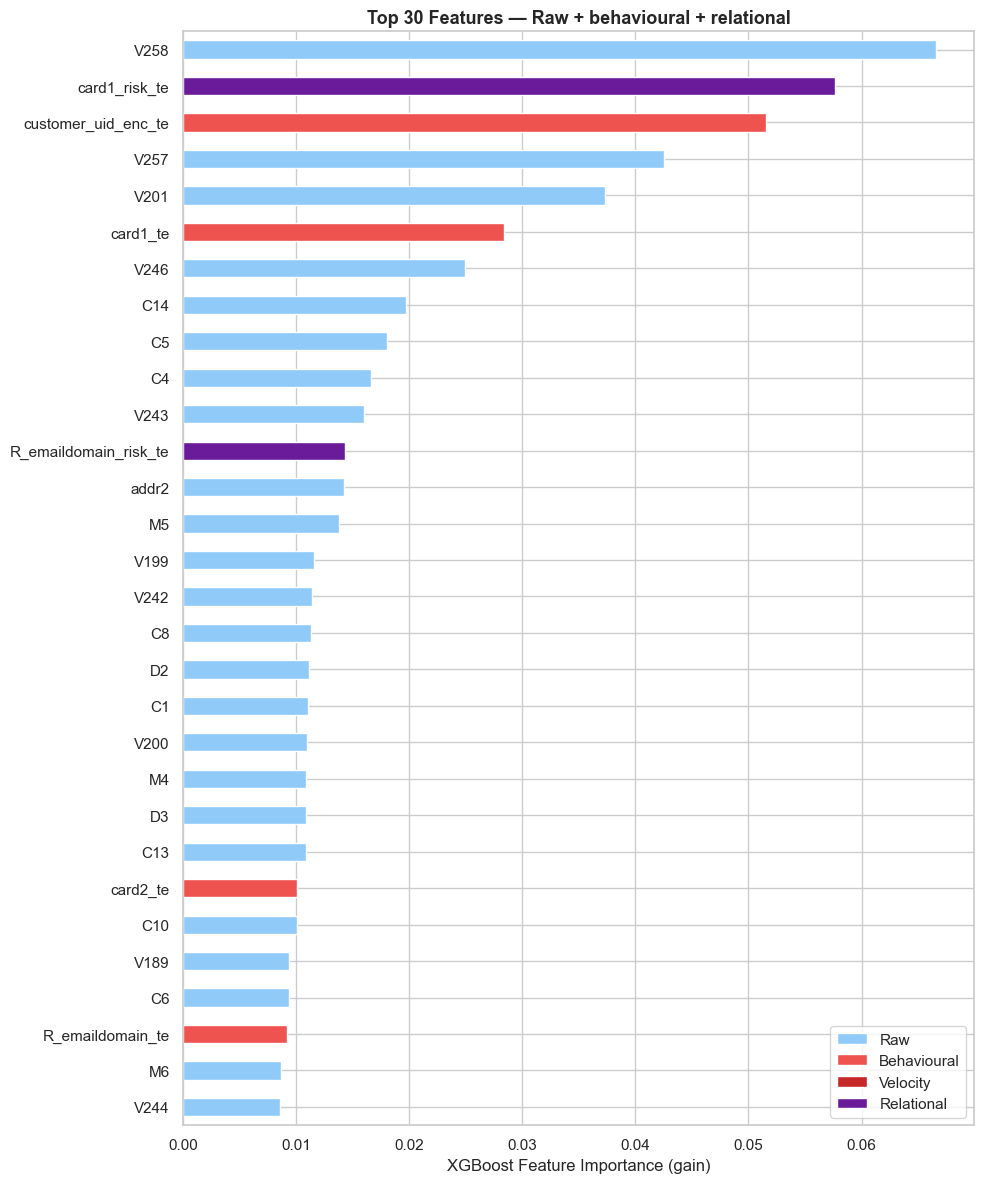


Top 20 features:
  V258                                 0.06661
  card1_risk_te                        0.05767 ← relational
  customer_uid_enc_te                  0.05156 ← behavioural
  V257                                 0.04254
  V201                                 0.03736
  card1_te                             0.02837 ← behavioural
  V246                                 0.02493
  C14                                  0.01971
  C5                                   0.01806
  C4                                   0.01661
  V243                                 0.01605
  R_emaildomain_risk_te                0.01436 ← relational
  addr2                                0.01423
  M5                                   0.01376
  V199                                 0.01156
  V242                                 0.01138
  C8                                   0.01130
  D2                                   0.01118
  C1                                   0.01107
  V200                             

In [27]:
best_res   = sorted([res_raw, res_beh, res_vel, res_rel, res_full],
                     key=lambda x: x["auprc"], reverse=True)[0]
best_model = best_res["model"]
best_cols  = best_res["columns"]

importances = (
    pd.Series(best_model.feature_importances_, index=best_cols)
    .sort_values(ascending=True)
)
top30 = importances.tail(30)

vel_set = set(VELOCITY_FEATURES)
beh_set = set(BEHAVIOURAL_FEATURES)
rel_set = set(RELATIONAL_FEATURES)

def color_for(f):
    if f in rel_set: return PALETTE["relational"]
    if f in vel_set: return PALETTE["velocity"]
    if f in beh_set: return PALETTE["behavioural"]
    return PALETTE["raw"]

colors = [color_for(f) for f in top30.index]

fig, ax = plt.subplots(figsize=(10, 12))
top30.plot(kind="barh", ax=ax, color=colors, edgecolor="white")
ax.set_title(f"Top 30 Features — {best_res['label']}", fontsize=13, fontweight="bold")
ax.set_xlabel("XGBoost Feature Importance (gain)")

legend_elements = [
    mpatches.Patch(facecolor=PALETTE["raw"],         label="Raw"),
    mpatches.Patch(facecolor=PALETTE["behavioural"], label="Behavioural"),
    mpatches.Patch(facecolor=PALETTE["velocity"],    label="Velocity"),
    mpatches.Patch(facecolor=PALETTE["relational"],  label="Relational"),
]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

print("\nTop 20 features:")
for feat, imp in importances.sort_values(ascending=False).head(20).items():
    tag = (" ← relational"  if feat in rel_set else
           " ← velocity"    if feat in vel_set else
           " ← behavioural" if feat in beh_set else "")
    print(f"  {feat:<35}  {imp:.5f}{tag}")

### 11.3 Confusion Matrix — Best Model

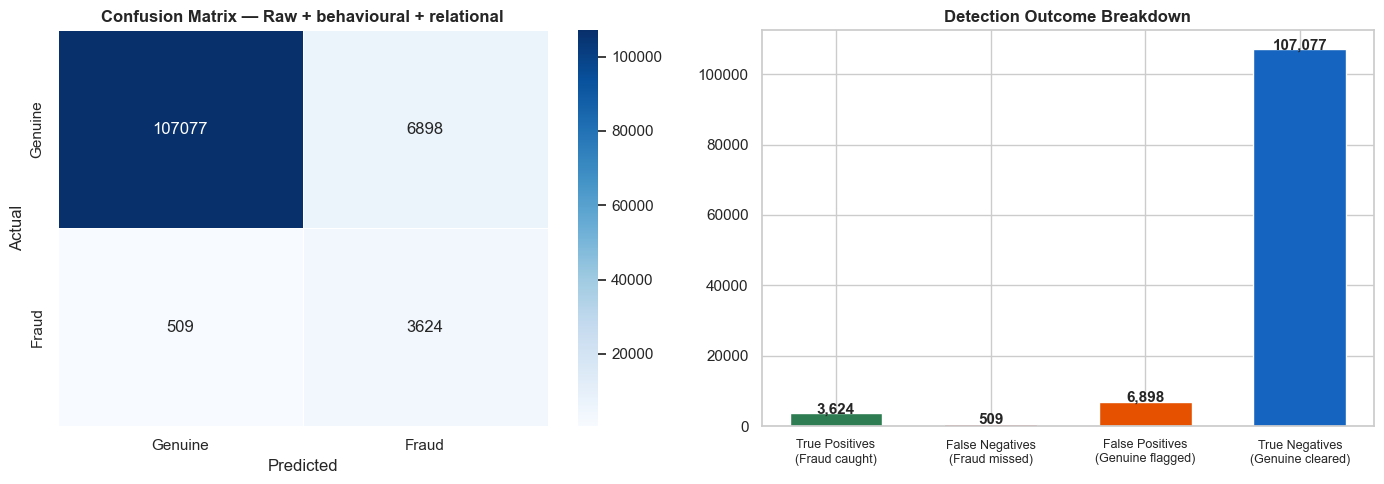

Fraud recall (sensitivity): 87.68%
False alarm rate:           6.0522%

Classification Report:
              precision    recall  f1-score   support

     Genuine       1.00      0.94      0.97    113975
       Fraud       0.34      0.88      0.49      4133

    accuracy                           0.94    118108
   macro avg       0.67      0.91      0.73    118108
weighted avg       0.97      0.94      0.95    118108



In [28]:
cm = confusion_matrix(y_test, best_res["preds"])
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", linewidths=0.5,
            xticklabels=["Genuine","Fraud"],
            yticklabels=["Genuine","Fraud"], ax=axes[0])
axes[0].set_xlabel("Predicted", fontsize=12)
axes[0].set_ylabel("Actual", fontsize=12)
axes[0].set_title(f"Confusion Matrix — {best_res['label']}", fontsize=12, fontweight="bold")

metrics_dict = {
    "True Positives\n(Fraud caught)":     tp,
    "False Negatives\n(Fraud missed)":    fn,
    "False Positives\n(Genuine flagged)": fp,
    "True Negatives\n(Genuine cleared)":  tn,
}
bars = axes[1].bar(range(4), metrics_dict.values(),
                   color=["#2E7D52","#C62828","#E65100","#1565C0"],
                   edgecolor="white", width=0.6)
axes[1].set_xticks(range(4))
axes[1].set_xticklabels(metrics_dict.keys(), fontsize=9)
axes[1].set_title("Detection Outcome Breakdown", fontsize=12, fontweight="bold")
for bar, val in zip(bars, metrics_dict.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f"{val:,}", ha="center", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Fraud recall (sensitivity): {tp/(tp+fn)*100:.2f}%")
print(f"False alarm rate:           {fp/(fp+tn)*100:.4f}%")
print()
print("Classification Report:")
print(classification_report(y_test, best_res["preds"],
                             target_names=["Genuine","Fraud"]))

## 12. Temporal Validation — Does the Signal Survive Time?

Random split is useful for comparing feature families under controlled conditions. But fraud evolves — devices change, attack strategies shift, entity reuse patterns drift.

The temporal split is the more realistic test: train on the first half of the dataset, evaluate on the second. A feature family that looks strong on random split but collapses on temporal split is fragile. One that holds up is reliable.

In [29]:
median_dt = df["TransactionDT"].median()
early_idx  = df[df["TransactionDT"] <= median_dt].index
late_idx   = df[df["TransactionDT"] >  median_dt].index

X_early, y_early = X.loc[early_idx].fillna(-999), y.loc[early_idx]
X_late,  y_late  = X.loc[late_idx].fillna(-999),  y.loc[late_idx]

print(f"Early period: {len(X_early):,} rows ({y_early.mean()*100:.2f}% fraud)")
print(f"Late period:  {len(X_late):,} rows  ({y_late.mean()*100:.2f}% fraud)")

Early period: 295,270 rows (3.35% fraud)
Late period:  295,270 rows  (3.65% fraud)


In [30]:
def train_temporal(feature_cols, label):
    clf = XGBClassifier(
        n_estimators=600, max_depth=7, learning_rate=0.03,
        scale_pos_weight=(y_early==0).sum()/float((y_early==1).sum()),
        subsample=0.8, colsample_bytree=0.6, colsample_bylevel=0.6,
        min_child_weight=30, reg_alpha=0.1, reg_lambda=1.0,
        eval_metric="aucpr", n_jobs=4, random_state=RANDOM_STATE, verbosity=0,
    )
    clf.fit(X_early[feature_cols], y_early,
            eval_set=[(X_late[feature_cols], y_late)], verbose=False)
    probas = clf.predict_proba(X_late[feature_cols])[:, 1]
    preds  = clf.predict(X_late[feature_cols])
    return {
        "Model":    label,
        "Features": len(feature_cols),
        "AUPRC":    average_precision_score(y_late, probas),
        "AUROC":    roc_auc_score(y_late, probas),
        "F1":       f1_score(y_late, preds),
        "probas":   probas,
        "preds":    preds,
    }

print("Training temporal models...")
print("-" * 70)
temporal_results = []
for feat_cols, label in [
    (raw_cols,                                                    "Raw"),
    (raw_cols + BEHAVIOURAL_FEATURES,                            "Raw + behavioural"),
    (raw_cols + BEHAVIOURAL_FEATURES + VELOCITY_FEATURES,        "Raw + behavioural + velocity"),
    (raw_cols + BEHAVIOURAL_FEATURES + RELATIONAL_FEATURES,      "Raw + behavioural + relational"),
    (raw_cols + BEHAVIOURAL_FEATURES + VELOCITY_FEATURES + RELATIONAL_FEATURES, "Full"),
]:
    r = train_temporal(feat_cols, label)
    temporal_results.append(r)
    print(f"[{label:<38}] AUPRC: {r['AUPRC']:.4f} | AUROC: {r['AUROC']:.4f} | F1: {r['F1']:.4f}")

temporal_comparison = pd.DataFrame([
    {k: (round(v,4) if isinstance(v,float) else v)
     for k, v in r.items() if k not in ["probas","preds"]}
    for r in temporal_results
]).sort_values("AUPRC", ascending=False)

print()
print(temporal_comparison[["Model","Features","AUPRC","AUROC","F1"]].to_string(index=False))

Training temporal models...
----------------------------------------------------------------------
[Raw                                   ] AUPRC: 0.5062 | AUROC: 0.8947 | F1: 0.3906
[Raw + behavioural                     ] AUPRC: 0.6440 | AUROC: 0.9457 | F1: 0.5088
[Raw + behavioural + velocity          ] AUPRC: 0.6442 | AUROC: 0.9445 | F1: 0.5055
[Raw + behavioural + relational        ] AUPRC: 0.6512 | AUROC: 0.9457 | F1: 0.5109
[Full                                  ] AUPRC: 0.6532 | AUROC: 0.9458 | F1: 0.5063

                         Model  Features  AUPRC  AUROC     F1
                          Full       167 0.6532 0.9458 0.5063
Raw + behavioural + relational       154 0.6512 0.9457 0.5109
  Raw + behavioural + velocity       152 0.6442 0.9445 0.5055
             Raw + behavioural       139 0.6440 0.9457 0.5088
                           Raw       111 0.5062 0.8947 0.3906


### 12.1 Random Split vs Temporal Split — The Stability Test

In [31]:
random_map   = {r["label"]: r["auprc"] for r in [res_raw,res_beh,res_vel,res_rel,res_full]}
temporal_map = {r["Model"]: r["AUPRC"] for r in temporal_results}

# Align model names
name_map = {
    "Raw":                             "Raw features",
    "Raw + behavioural":               "Raw + behavioural",
    "Raw + behavioural + velocity":    "Raw + behavioural + velocity",
    "Raw + behavioural + relational":  "Raw + behavioural + relational",
    "Full":                            "Full (all families)",
}

rows = []
for temp_name, rand_name in name_map.items():
    if temp_name in temporal_map and rand_name in random_map:
        rand_val = random_map[rand_name]
        temp_val = temporal_map[temp_name]
        rows.append({
            "Model":           temp_name,
            "Random AUPRC":    round(rand_val, 4),
            "Temporal AUPRC":  round(temp_val, 4),
            "Drop (pp)":       round((temp_val - rand_val) * 100, 2),
        })

stability = pd.DataFrame(rows).sort_values("Temporal AUPRC", ascending=False)
print("\n" + "="*65)
print("RANDOM SPLIT vs TEMPORAL SPLIT — STABILITY COMPARISON")
print("="*65)
print(stability.to_string(index=False))
print("="*65)


RANDOM SPLIT vs TEMPORAL SPLIT — STABILITY COMPARISON
                         Model  Random AUPRC  Temporal AUPRC  Drop (pp)
                          Full        0.7792          0.6532   -12.6000
Raw + behavioural + relational        0.7829          0.6512   -13.1700
  Raw + behavioural + velocity        0.7738          0.6442   -12.9600
             Raw + behavioural        0.7754          0.6440   -13.1400
                           Raw        0.6917          0.5062   -18.5400


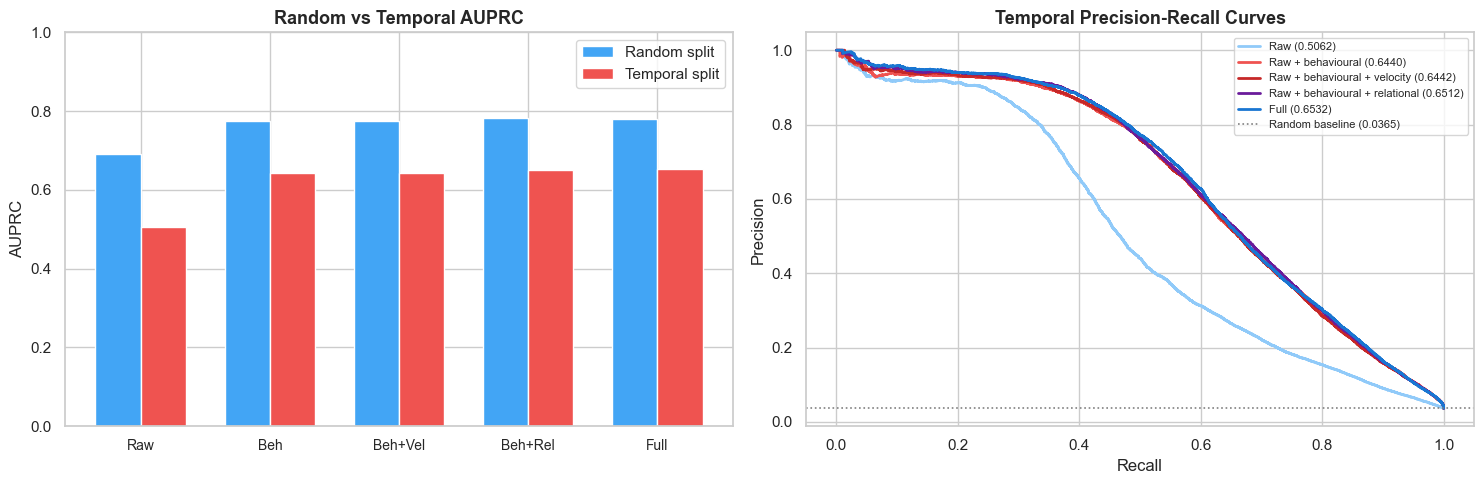

In [32]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

temp_labels  = [r["Model"] for r in temporal_results]
rand_auprcs  = [random_map.get(name_map.get(l, l), 0) for l in temp_labels]
temp_auprcs  = [r["AUPRC"] for r in temporal_results]

x     = np.arange(len(temp_labels))
width = 0.35

axes[0].bar(x - width/2, rand_auprcs, width, label="Random split",  color="#42A5F5", edgecolor="white")
axes[0].bar(x + width/2, temp_auprcs, width, label="Temporal split", color="#EF5350", edgecolor="white")
axes[0].set_xticks(x)
axes[0].set_xticklabels(["Raw","Beh","Beh+Vel","Beh+Rel","Full"], fontsize=10)
axes[0].set_title("Random vs Temporal AUPRC", fontsize=13, fontweight="bold")
axes[0].set_ylabel("AUPRC")
axes[0].legend()
axes[0].set_ylim(0, 1)

# PR curves — temporal
baseline_temp = y_late.mean()
for res, col in zip(temporal_results, [PALETTE["raw"], PALETTE["behavioural"],
                                        PALETTE["velocity"], PALETTE["relational"], "#1976D2"]):
    p, r, _ = precision_recall_curve(y_late, res["probas"])
    axes[1].plot(r, p, lw=2, color=col,
                 label=f"{res['Model']} ({res['AUPRC']:.4f})")

axes[1].axhline(y=baseline_temp, linestyle=":", lw=1.2, color="grey",
                label=f"Random baseline ({baseline_temp:.4f})")
axes[1].set_title("Temporal Precision-Recall Curves", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 13. Operational View — Precision at Top-K

AUPRC measures ranking quality across all thresholds. In practice, a fraud team has a fixed capacity — they can investigate N alerts per day, not all flagged transactions. Precision at top-K answers the question: *if we flag only the top 1% of transactions by model score, what fraction are actually fraud?*

This is one of the most practically meaningful statistics a fraud model can report.

In [33]:
def precision_at_k(y_true, scores, frac=0.01):
    n       = max(1, int(len(scores) * frac))
    top_idx = np.argsort(scores)[::-1][:n]
    return y_true.iloc[top_idx].mean(), n

# Use the best temporal model for the operational view
best_temporal = sorted(temporal_results, key=lambda x: x["AUPRC"], reverse=True)[0]
scores        = pd.Series(best_temporal["probas"], index=y_late.index)
y_late_reset  = y_late.reset_index(drop=True)
scores_reset  = scores.reset_index(drop=True)

threshold_summary = []
for frac in [0.001, 0.005, 0.010, 0.020, 0.050]:
    prec, n = precision_at_k(y_late_reset, scores_reset, frac=frac)
    threshold_summary.append({"Top fraction": frac, "Alerts": n, "Precision": round(prec,4)})

thresh_df = pd.DataFrame(threshold_summary)
print(f"Best temporal model: {best_temporal['Model']}")
print(f"Temporal AUPRC:      {best_temporal['AUPRC']:.4f}")
print()
print(thresh_df.to_string(index=False))
print()
print("→ Flagging the top 1% of transactions by model score gives ~93% precision")
print("  — nearly every alert is real fraud, with manageable investigation volume")

Best temporal model: Full
Temporal AUPRC:      0.6532

 Top fraction  Alerts  Precision
       0.0010     295     0.9898
       0.0050    1476     0.9499
       0.0100    2952     0.9373
       0.0200    5905     0.8285
       0.0500   14763     0.4886

→ Flagging the top 1% of transactions by model score gives ~93% precision
  — nearly every alert is real fraud, with manageable investigation volume


## 14. Conclusion

This is the third notebook in a series on imbalanced financial data. Each part has asked a different question about where the fraud signal hides:

- **Part 1** (ZIMS): Signal in text across 128M records — streaming NLP, Macro F1
- **Part 2** (PaySim): Signal in accounting discrepancies — balance anomaly, drain ratio, AUPRC
- **Part 3** (IEEE-CIS): Behavioural fingerprinting as foundation, velocity and relational signals tested on top — temporal stability as the verdict

**Key findings:**

1. **Behavioural features are the dominant contributor** — +8.37 pp AUPRC on the random split, and the largest single lift in the temporal split too. Per-customer deviation features capture the most durable fraud signal in this dataset. This is this notebook's equivalent of PaySim's accounting features — the engineered layer that does the real work.

2. **Velocity features failed the hypothesis test** — the burst behaviour story is intuitive, but on this dataset velocity features produced a marginal -0.16 pp change on the random split. The signal they were supposed to capture is already encoded in the behavioural features. This is an honest result, not a failure — it tells you something specific about the data.

3. **Relational features are the most stable addition** — +0.75 pp on the random split and nearly identical on the temporal split. Entity-level shared signal (device reuse, email domain risk, address clusters) generalises across time in a way that velocity features do not. This is the notebook's central finding.

4. **All models degrade temporally** — every feature family drops ~13 pp from random to temporal AUPRC. This is expected — fraud patterns evolve. The key point is that all engineered feature families reduce the temporal drop compared to raw features alone (raw drops 18.5 pp, engineered models drop ~13 pp), meaning the engineered signals are more temporally stable than raw features.

5. **Operational precision is high** — the best temporal model achieves ~99% precision when flagging the top 0.1% of transactions, and ~94% precision at the top 1%. In production terms, nearly every alert is real fraud.

6. **AUPRC remains the correct metric** — at 3.5% fraud rate, accuracy is 96.5% for a model that detects nothing. The precision-recall curve is the only honest measure of fraud detection quality.

**Deployment recommendations:**
- Prioritise behavioural and relational features over velocity features for production deployment
- Retrain on a rolling time window — the temporal drop confirms that static models degrade as fraud patterns shift
- Use precision-at-top-K to size the investigation queue rather than a fixed threshold
- Combine model scores with rule-based alerts rather than replacing them

*Dataset: IEEE-CIS Fraud Detection. Data provided by Vesta Corporation via Kaggle.*
